In [46]:
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
from snsphd.viz import phd_style

from util.pcr_loader import PcrLoader

colors, swatches = phd_style(jupyterStyle=True)

SHOW_DARK = False
X_LIMITS = None
Y_LIMITS = None

DATASETS = {
    "35 um": {
        "path": "../data/DC_Pa250528a_60nm_hero/35um/6_1snap_w0.06_l50_35micron_1.9thermal_start_265_end_XXX.csv",
        "threshold": 0.010,
    },
    "42 um": {
        "path": "../data/DC_Pa250528a_60nm_hero/42um/6_1snap_w0.06_l50_42um_2.2thermal_start_261_end_XXX.csv",
        "threshold": 0.012,
    },
    "46 um": {
        "path": "../data/DC_Pa250528a_60nm_hero/46um_QCL/2.11.2026/qcl_30Hz_280mA_30.0V__0.002_time_10s_x6cycles_start_258mK.csv",
        "threshold": 0.011,
    },
    "63 um": {
        "path": "../data/DC_Pa250528a_60nm_hero/63um_QCL/qcl_80Hz_29.6mA_6.23V_0.002_integration_2s_cycles_8_start_249mK.csv",
        "threshold": 0.012,
    },
}

PLOT_COLORS = {
    "35 um": plt.cm.plasma(0.15),
    "42 um": plt.cm.plasma(0.40),
    "46 um": plt.cm.plasma(0.65),
    "63 um": plt.cm.plasma(0.90),
}
MARKERS = {
    "35 um": "o",
    "42 um": "^",
    "46 um": "D",
    "63 um": "s",
}




The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [47]:
# Load each CSV once so threshold maps are easy to inspect.
datasets = {label: PcrLoader.from_threshold_csv(spec["path"]) for label, spec in DATASETS.items()}

for label, dataset in datasets.items():
    print(label, dataset.threshold_map())


35 um {1: 0.007, 2: 0.008, 3: 0.01}
42 um {1: 0.008, 2: 0.01, 3: 0.012}
46 um {1: 0.011, 2: 0.012, 3: 0.014}
63 um {1: 0.008, 2: 0.01, 3: 0.012, 4: 0.014}


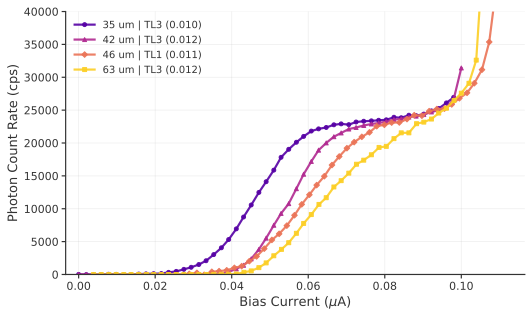

In [78]:

SCALE_FACTOR = {
    "35 um": 1.0,
    "42 um": 0.85,
    "46 um": 0.71,
    "63 um": 0.65,
}

OFFSET_X = {
    "35 um": 0,
    "42 um": 0,
    "46 um": 0.024,
    "63 um": 0.001,
}

OFFSET_Y = {
    "35 um": 0,
    "42 um": 0,
    "46 um": -12700,
    "63 um": 0,
}

# SCALE_FACTOR = {
#     "35 um": 1.0,
#     "42 um": 1,
#     "46 um": 1,
#     "63 um": 1,
# }

# OFFSET_X = {
#     "35 um": 0,
#     "42 um": 0,
#     "46 um": 0,
#     "63 um": 0,
# }

CROP_END = {
    "35 um": -5,
    "42 um": -4,
    "46 um": -1,
    "63 um": -1,
}

# These manual tweaks align the four device curves on one figure.
curves = {
    label: datasets[label].get_curve(spec["threshold"], label=label)
    for label, spec in DATASETS.items()
}


fig, ax = plt.subplots(figsize=(7.5, 4.5))
ax_dark = ax.twinx()
ax_dark.set_visible(SHOW_DARK)

for label, curve in curves.items():
    ax.plot(
        curve.bias_uA[:CROP_END[label]] + OFFSET_X[label],
        # Shift/scale after cropping so only the comparison window moves.
        (curve.counts[:CROP_END[label]] + OFFSET_Y[label])*SCALE_FACTOR[label],
        marker=MARKERS[label],
        color=PLOT_COLORS[label],
        linewidth=2.2,
        markersize=4,
        alpha=0.9,
        label=f"{label} | {curve.threshold.label}",
    )
    if SHOW_DARK and curve.dark_counts is not None:
        ax_dark.plot(
            curve.bias_uA,
            curve.dark_counts,
            marker="x",
            color=PLOT_COLORS[label],
            linewidth=1.8,
            markersize=4,
            alpha=0.6,
            linestyle="--",
            label=f"DCR {label}",
        )

ax.set_xlabel(r"Bias Current ($\mu$A)")
ax.set_ylabel("Photon Count Rate (cps)")
if X_LIMITS is not None:
    ax.set_xlim(*X_LIMITS)
if Y_LIMITS is not None:
    ax.set_ylim(*Y_LIMITS)
ax.legend(frameon=False, loc="upper left", fontsize=10)
ax.grid(alpha=0.2)

if SHOW_DARK:
    ax_dark.set_yscale("log")
    ax_dark.set_ylabel("Dark Count Rate (cps)")
    ax_dark.legend(frameon=False, loc="lower right", fontsize=10)


ax.set_ylim(0, 40000)
plt.tight_layout()

out_dir = Path("../out/60nm_hero")
out_dir.mkdir(parents=True, exist_ok=True)
fig.savefig(out_dir / "hero_35_42_46_63um_counts.png", dpi=300)
fig.savefig(out_dir / "hero_35_42_46_63um_counts.pdf", dpi=300)
plt.show()